# Linear Regression Playground

Interactive environment to step through the `linear_regression.py` pipeline for Retail Forecasting.

In [1]:
import os
import sys
import pandas as pd

# Point to project root
PROJECT_ROOT = os.path.dirname(os.path.abspath(''))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.models.linear_regression import (
    preprocess_and_split, train_models, predict_models, evaluate_models
)
from src.tools.visualization import plot_cluster_portfolio, analyze_time_periods

Importing plotly failed. Interactive plots will not work.


## 1. Load Processed Data

In [2]:
data_path = os.path.join(PROJECT_ROOT, 'data', 'processed_retail_data.parquet')
df_long = pd.read_parquet(data_path)
df_long.head()

,StockCode,Week,Quantity,Revenue,week_of_year,month,quarter,year,sin_woy,cos_woy,...,rstd_26,price_weekly,price_relative_to_historical,price_percent_change,is_on_promotion,profile_cluster_id,volume_cluster_id,volume_tier,semantic_cluster_id,semantic_cluster_name
0,10002,2009-11-30,141,119.85,49,11,4,2009,-3.546049e-01,0.935016,...,0.000000,0.85,1.0,0.0,0,2,1,Medium,3,SET + BOX + PACK
1,10002,2009-12-07,24,21.25,50,12,4,2009,-2.393157e-01,0.970942,...,0.000000,0.85,1.0,0.0,0,2,1,Medium,3,SET + BOX + PACK
2,10002,2009-12-14,37,32.30,51,12,4,2009,-1.205367e-01,0.992709,...,82.731493,0.85,1.0,0.0,0,2,1,Medium,3,SET + BOX + PACK
3,10002,2009-12-21,14,12.75,52,12,4,2009,6.432491e-16,1.000000,...,64.127477,0.85,1.0,0.0,0,2,1,Medium,3,SET + BOX + PACK
4,10002,2009-12-28,0,0.00,53,12,4,2009,1.205367e-01,0.992709,...,58.759396,NaN,NaN,0.0,0,2,1,Medium,3,SET + BOX + PACK


## 2. Preprocess & Split
Scales the continuous features (MinMaxScaler) per StockCode and drops unnecessary columns.

In [3]:
train, test, X_train, y_train, X_test, sku_scalers, feature_cols = preprocess_and_split(df_long)
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Feature Engineering and Train/Test Split...


Scaling SKUs: 100%|██████████| 4873/4873 [01:31<00:00, 53.54it/s]


Training shape: (448316, 34)
Testing shape:  (68222, 34)
Train shape: (448316, 34)
Test shape: (68222, 34)


## 3. Train Models per Seasonal Profile

In [4]:
cluster_models = train_models(X_train, y_train, train)

Training Linear Regression models per Seasonal Profile Cluster...
 - Model for Cluster 0 trained on 179584 historical rows.
 - Model for Cluster 1 trained on 43240 historical rows.
 - Model for Cluster 2 trained on 86112 historical rows.
 - Model for Cluster 3 trained on 81880 historical rows.
 - Model for Cluster 4 trained on 57500 historical rows.


## 4. Predict on Test Set

In [5]:
test = predict_models(cluster_models, test, X_test, sku_scalers)

Predicting on Test Set...
Applying physical constraints (Capping at 0)...
Predictions Complete!


/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/opt/anaconda3/envs/columbia/lib/python3.13/site-packages/sklearn/linear_model/_base.py:293: Runti

## 5. Evaluate (MAPE & WMAPE)

In [6]:
cluster_eval, summary = evaluate_models(test, sku_scalers, train)
display(summary)


Evaluating model (raw Quantity)...


,Portfolio_MAPE,Portfolio_WMAPE
Cluster,,
Global,115.56,153.18
0,113.15,92.65
1,13.71,12.14
2,348.43,360.47
3,45.98,42.11
4,56.51,54.94


## 6. Visualization

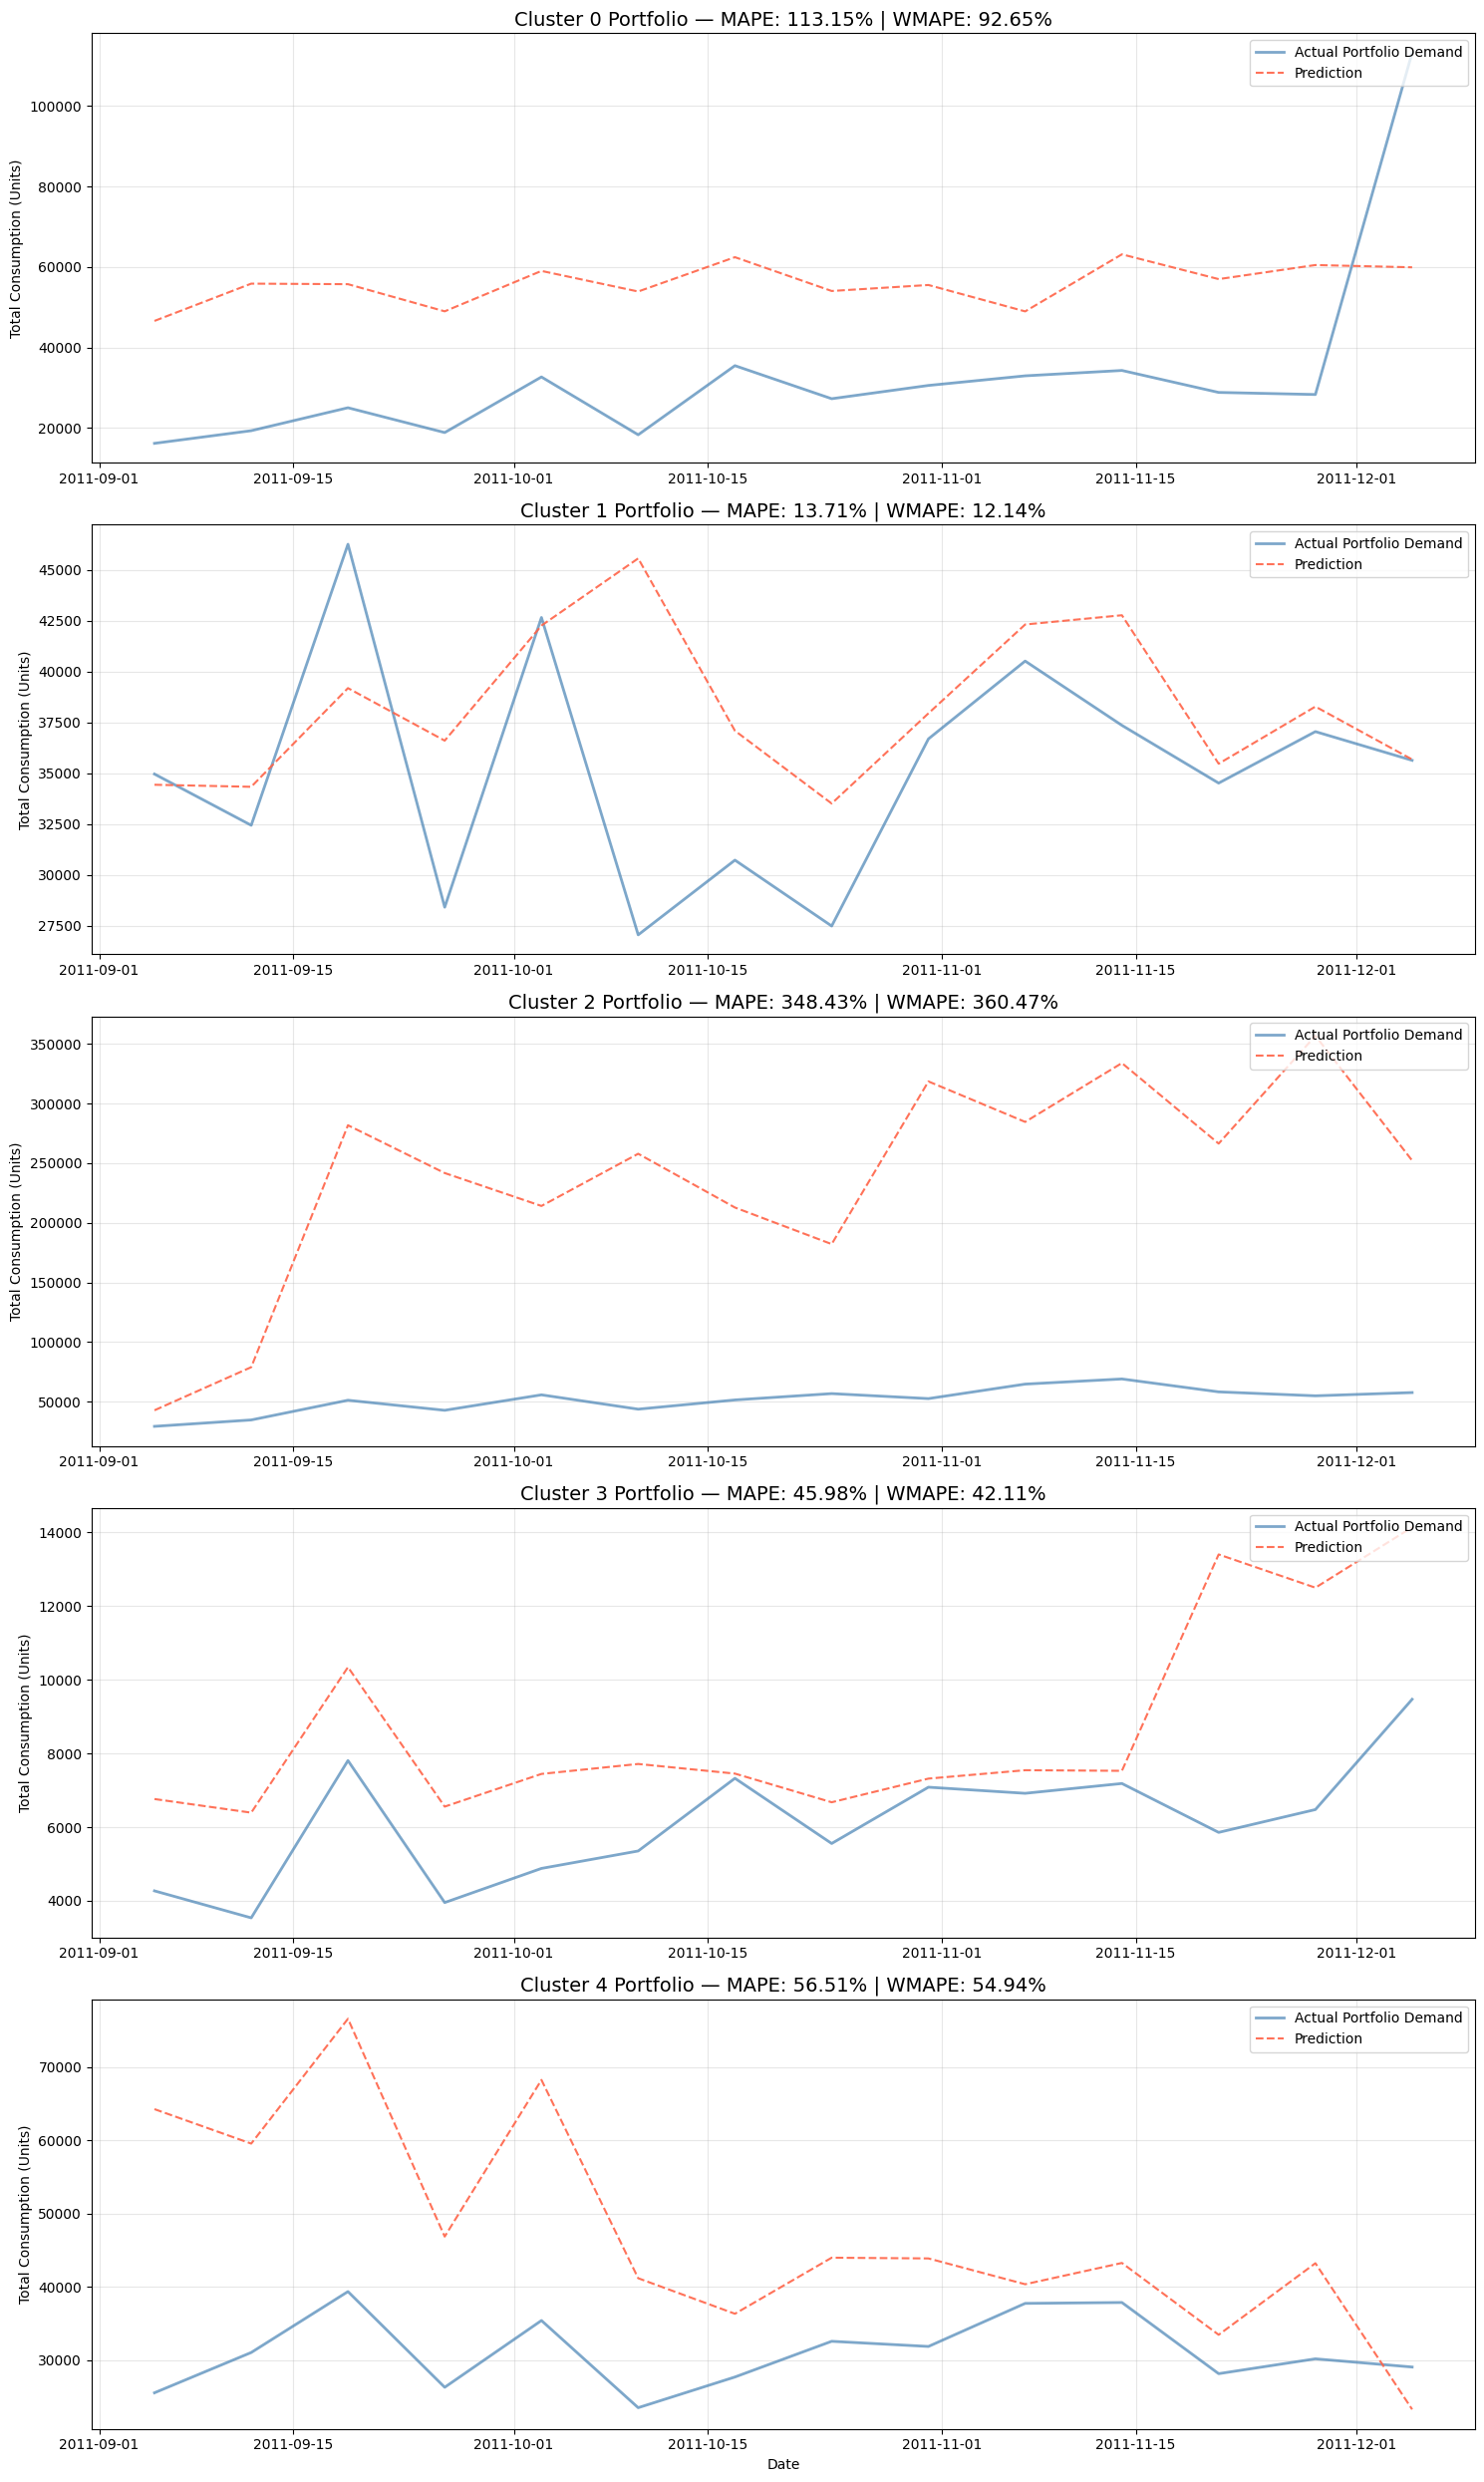

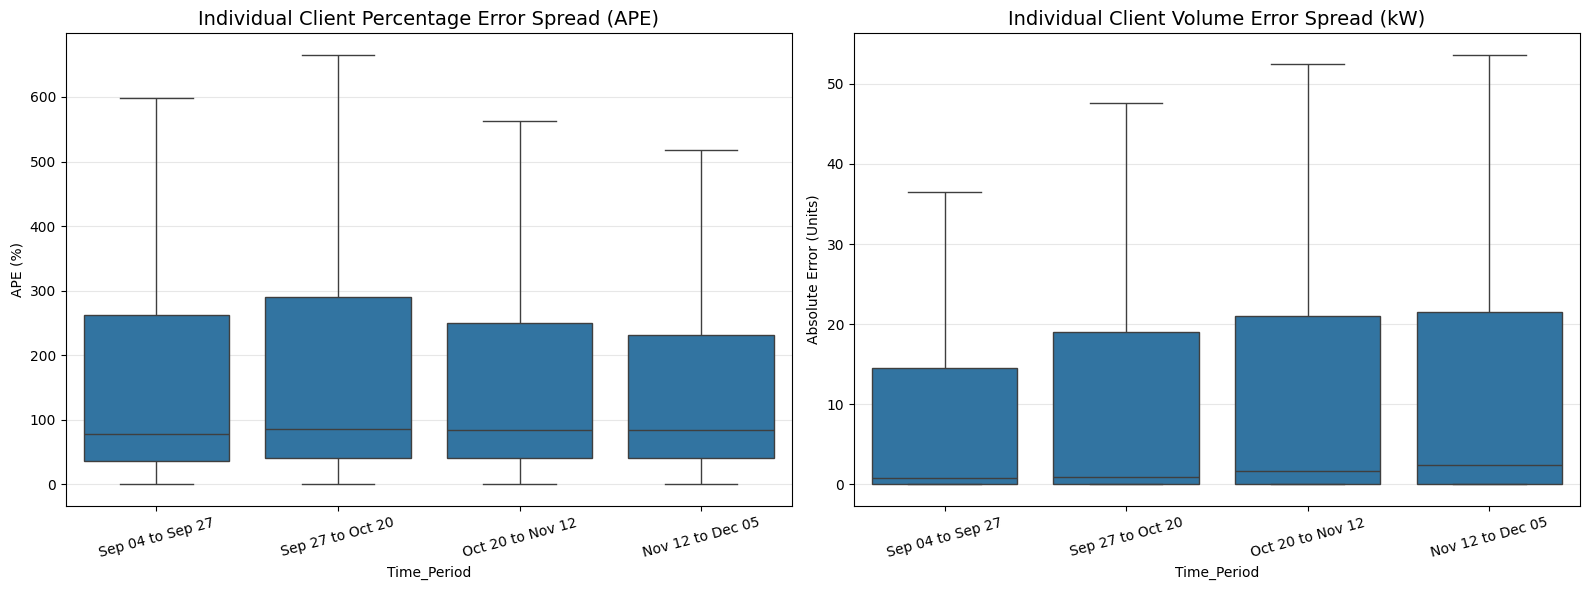

,MAPE,WMAPE
Time_Period,,
Sep 04 to Sep 27,507.64,204.75
Sep 27 to Oct 20,553.52,228.30
Oct 20 to Nov 12,464.30,212.66
Nov 12 to Dec 05,480.86,225.01


In [7]:
plot_cluster_portfolio(cluster_eval, summary, n_steps_to_show=52)
analyze_time_periods(test)